In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

c:\Users\Dell\LangGraph\env0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.2)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [13]:
def generate_answer(state: ParentState):

    answer = subgraph_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [14]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [15]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

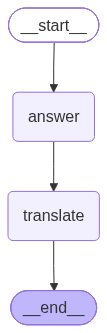

In [16]:
graph = parent_builder.compile()

graph

In [17]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the atomic and subatomic levels.\n\nHere\'s a breakdown of what that means:\n\n1.  **The "Quantum" Part:** The word "quantum" comes from Latin, meaning "how much." In quantum physics, it refers to the idea that certain physical properties, like energy, momentum, and angular momentum, are not continuous but come in discrete, indivisible packets or "quanta." Think of it like a staircase instead of a ramp – you can only be on specific steps, not anywhere in between.\n\n2.  **The "Physics" Part:** It\'s a branch of physics because it seeks to understand the fundamental laws governing the universe. However, it deals with a realm where the rules are very different from what we experience in our everyday macroscopic world.\n\n**Key Ideas and Concepts (The "Weirdness"):**\n\n*   **Quantization:** As ment